In [273]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv("housing.csv")
print("Everything is working!")

Everything is working!


In [274]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [275]:
df.isnull().sum()
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df.isnull().sum()
df.shape

(20640, 10)

In [276]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']
upper_limit = y.quantile(0.99)
mask = y < upper_limit
X = X[mask]
y = y[mask]
print(X.shape)
print(y.shape)

(19675, 9)
(19675,)


In [277]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [278]:
num_features = X_train.select_dtypes(include=['float64', 'int64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

In [279]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler())
])
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", OneHotEncoder(), cat_features),
])

In [280]:
X_train_processed = full_pipeline.fit_transform(X_train)
X_test_processed = full_pipeline.transform(X_test)

1. Linear Regression

In [281]:
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)

lr_pred = lr_model.predict(X_test_processed)

print("Linear Regression:")
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression:
MSE: 3914036126.8086524
R2 Score: 0.607457457139063


2. Random Forest

In [282]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_processed, y_train)

rf_pred = rf_model.predict(X_test_processed)

print("Random Forest:")
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest:
MSE: 2107738967.9015162
R2 Score: 0.7886127804288413


3. Gradient Boosting

In [283]:
gb_model = GradientBoostingRegressor(n_estimators=300,learning_rate=0.05,max_depth=4,random_state=42)
gb_model.fit(X_train_processed, y_train)

gb_pred = gb_model.predict(X_test_processed)

print("Gradient Boosting:")
print("MSE:", mean_squared_error(y_test, gb_pred))
print("R2 Score:", r2_score(y_test, gb_pred))

Gradient Boosting:
MSE: 2173530861.5956717
R2 Score: 0.7820144465316532


192477.92101651843


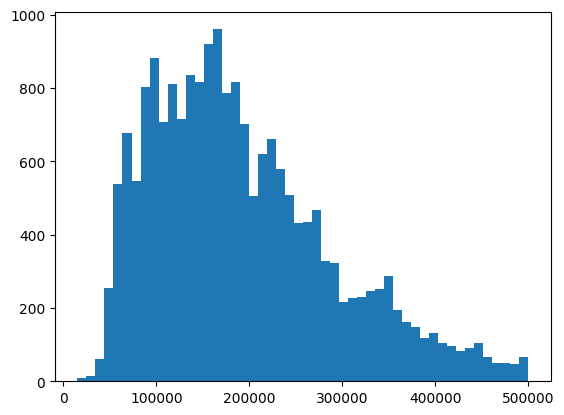

In [284]:
print(y.mean())
plt.hist(y, bins=50)
plt.show()